# Deklaracje

| Ex1 | Ex2 | Ex3 | Ex4 | Ex5 |
| --- | --- | --- | --- | --- |
| ✅  | ✅  | ✅ | ✅ | --- |

# Ex1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [177]:
titanic_df = pd.read_csv('Titanic Dataset.csv')
titanic_df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [133]:
columns_with_nan = [c for c in titanic_df.columns if titanic_df[c].isna().any()]
columns_with_nan

['age', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

In [178]:
def map_value_based_on_sex(column_name : str):
    mean_men = int(titanic_df[titanic_df['sex'] == 'male'][column_name].mean(axis=0, skipna=True))
    mean_women = int(titanic_df[titanic_df['sex'] == 'female'][column_name].mean(axis=0, skipna=True))
    
    mapping = {'male': mean_men, 'female': mean_women}
    mask = pd.isna(titanic_df[column_name])
    
    titanic_df.loc[mask, column_name] = titanic_df.loc[mask, 'sex'].map(mapping)

def set_bool_nan(column_name):
    titanic_df[column_name] = pd.isna(titanic_df[column_name])
   
map_value_based_on_sex('age')
map_value_based_on_sex('fare')
map_value_based_on_sex('body')

set_bool_nan('cabin')
set_bool_nan('embarked')
set_bool_nan('boat')
set_bool_nan('home.dest')

titanic_df.drop(columns=['ticket', 'name'], inplace=True)
titanic_df.head()


,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,boat,body,home.dest
0,1,1,female,29.00,0,0,211.3375,False,False,False,166.0,False
1,1,1,male,0.92,1,2,151.5500,False,False,False,160.0,False
2,1,0,female,2.00,1,2,151.5500,False,False,True,166.0,False
3,1,0,male,30.00,1,2,151.5500,False,False,True,135.0,False
4,1,0,female,25.00,1,2,151.5500,False,False,True,166.0,False


In [179]:
columns_with_nan = [c for c in titanic_df.columns if titanic_df[c].isna().any()]
columns_with_nan

[]

### Devide into equal bins

In [ ]:
def change_numeric_to_equal_bins(columns: list[str], k: int):
    titanic_all_eq = titanic_df.copy()
    for col in columns:
        _, bins = pd.qcut(
            titanic_all_eq[col], q=k, retbins=True, duplicates='drop'
        )
        
        n_bins = len(bins) - 1
        print(n_bins)
        labels = list(range(n_bins))
        titanic_all_eq[col] = pd.qcut(
            titanic_all_eq[col], q=n_bins, labels=labels, duplicates='drop'
        )
        titanic_all_eq[col] = titanic_all_eq[col].astype(int)
    return pd.get_dummies(titanic_all_eq)

titanic_all_eq = change_numeric_to_equal_bins(['age', 'fare', 'body'], 4)
titanic_all_eq.head()

4
4
3


,pclass,survived,age,sibsp,parch,fare,cabin,embarked,boat,body,home.dest,sex_female,sex_male
0,1,1,1,0,0,3,False,False,False,1,False,True,False
1,1,1,0,1,2,3,False,False,False,0,False,False,True
2,1,0,0,1,2,3,False,False,True,1,False,True,False
3,1,0,1,1,2,3,False,False,True,0,False,False,True
4,1,0,1,1,2,3,False,False,True,1,False,True,False


### Devide into equal frequently bins

In [192]:

def label_based_on_quantile(row, quantiles):
    for i in range(len(quantiles)):
        if row <= quantiles[i]:
            return i


def get_quanitles_for_bins_no(column, number_of_bins):
    quantiles = np.linspace(0, 1, number_of_bins + 1)[1:]
    return np.quantile(column, quantiles)

def change_numeric_columns_into_eq_freq_classes(columns : list[str], k : int):
    titanic_eq_freq = titanic_df.copy()
    
    for col in columns:
        titanic_eq_freq[col] = titanic_eq_freq[col].apply(
            lambda row: label_based_on_quantile(
                row, get_quanitles_for_bins_no(titanic_eq_freq[col], k)))

        return pd.get_dummies(titanic_eq_freq)
    
titanic_eq_freq = change_numeric_columns_into_eq_freq_classes(['age', 'fare', 'body'], 4)
titanic_eq_freq.head()

,pclass,survived,age,sibsp,parch,fare,cabin,embarked,boat,body,home.dest,sex_female,sex_male
0,1,1,1,0,0,211.3375,False,False,False,166.0,False,True,False
1,1,1,0,1,2,151.5500,False,False,False,160.0,False,False,True
2,1,0,0,1,2,151.5500,False,False,True,166.0,False,True,False
3,1,0,1,1,2,151.5500,False,False,True,135.0,False,False,True
4,1,0,1,1,2,151.5500,False,False,True,166.0,False,True,False


### Clustering every numeric variable

In [189]:
from sklearn.cluster import KMeans


def cluster_numeric_columns(numeric_columns : list[str], k : int):
    titanic_cluster = titanic_df.copy()
    
    for col_name in numeric_columns:
        kmeans = KMeans(n_clusters=k, random_state=42)
        titanic_cluster[col_name] = kmeans.fit_predict(titanic_cluster[[col_name]])
        
    return pd.get_dummies(titanic_cluster)

titanic_cluster = cluster_numeric_columns(['age', 'fare', 'body'], 4)
titanic_cluster.head()

,pclass,survived,age,sibsp,parch,fare,cabin,embarked,boat,body,home.dest,sex_female,sex_male
0,1,1,2,0,0,2,False,False,False,3,False,True,False
1,1,1,3,1,2,1,False,False,False,1,False,False,True
2,1,0,3,1,2,1,False,False,True,3,False,True,False
3,1,0,2,1,2,1,False,False,True,1,False,False,True
4,1,0,1,1,2,1,False,False,True,3,False,True,False


## Printing Results

In [180]:
from sklearn.model_selection import train_test_split
import sklearn.metrics as skm
from sklearn.naive_bayes import CategoricalNB

def split_features_and_target(titanic_data: pd.DataFrame):
    X_titanic, y_titanic = titanic_data.drop(columns=['survived']), titanic_data['survived']
    X_train, X_test, y_train, y_test = train_test_split(X_titanic, y_titanic, random_state=42, test_size=0.2)
    return X_train, X_test, y_train, y_test

def train_and_evaluate_model(X_train, X_test, y_train, y_test, model_name='None'):
    clf = CategoricalNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = skm.accuracy_score(y_test, y_pred)
    precision = skm.precision_score(y_test, y_pred)
    recall = skm.recall_score(y_test, y_pred)
    f1 = skm.f1_score(y_test, y_pred)
    
    return dict(model=model_name, accuracy=accuracy, precision=precision, recall=recall, f1=f1)

In [301]:
all_results = []
k_list = [2, 5, 10]
numeric_columns = ["age", "fare", "body"]

for k in k_list:
    titanic_all_eq = change_numeric_to_equal_bins(numeric_columns, k)
    X_train, X_test, y_train, y_test = split_features_and_target(titanic_all_eq)
    equal_bins_results = train_and_evaluate_model(
        X_train, X_test, y_train, y_test, model_name=f"Bin Equal with k={k}"
    )

    titanic_eq_freq = change_numeric_columns_into_eq_freq_classes(numeric_columns, k)
    X_train, X_test, y_train, y_test = split_features_and_target(titanic_eq_freq)
    freq_equal_results = train_and_evaluate_model(
        X_train, X_test, y_train, y_test, model_name=f"Freq Equal with k={k}"
    )

    titanic_cluster = cluster_numeric_columns(numeric_columns, k)
    X_train, X_test, y_train, y_test = split_features_and_target(titanic_cluster)
    clustered_results = train_and_evaluate_model(
        X_train, X_test, y_train, y_test, model_name=f"Clustered with k={k}"
    )

    all_results.extend([equal_bins_results, freq_equal_results, clustered_results])

df = pd.DataFrame(all_results)
df

2
2
2
5
5
3
9
10
3


,model,accuracy,precision,recall,f1
0,Bin Equal with k=2,0.893130,0.959184,0.796610,0.870370
1,Freq Equal with k=2,0.900763,0.960000,0.813559,0.880734
2,Clustered with k=2,0.938931,0.990385,0.872881,0.927928
3,Bin Equal with k=5,0.896947,0.950495,0.813559,0.876712
4,Freq Equal with k=5,0.896947,0.959596,0.805085,0.875576
5,Clustered with k=5,0.916031,0.952830,0.855932,0.901786
6,Bin Equal with k=10,0.900763,0.950980,0.822034,0.881818
7,Freq Equal with k=10,0.896947,0.959596,0.805085,0.875576
8,Clustered with k=10,0.893130,0.950000,0.805085,0.871560


# Ex2

In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [303]:
from pathlib import Path

directory = Path('ex2_data_index')
files = [f for f in directory.iterdir() if f.is_file()]

Xs = [np.load(str(f)) for f in files]

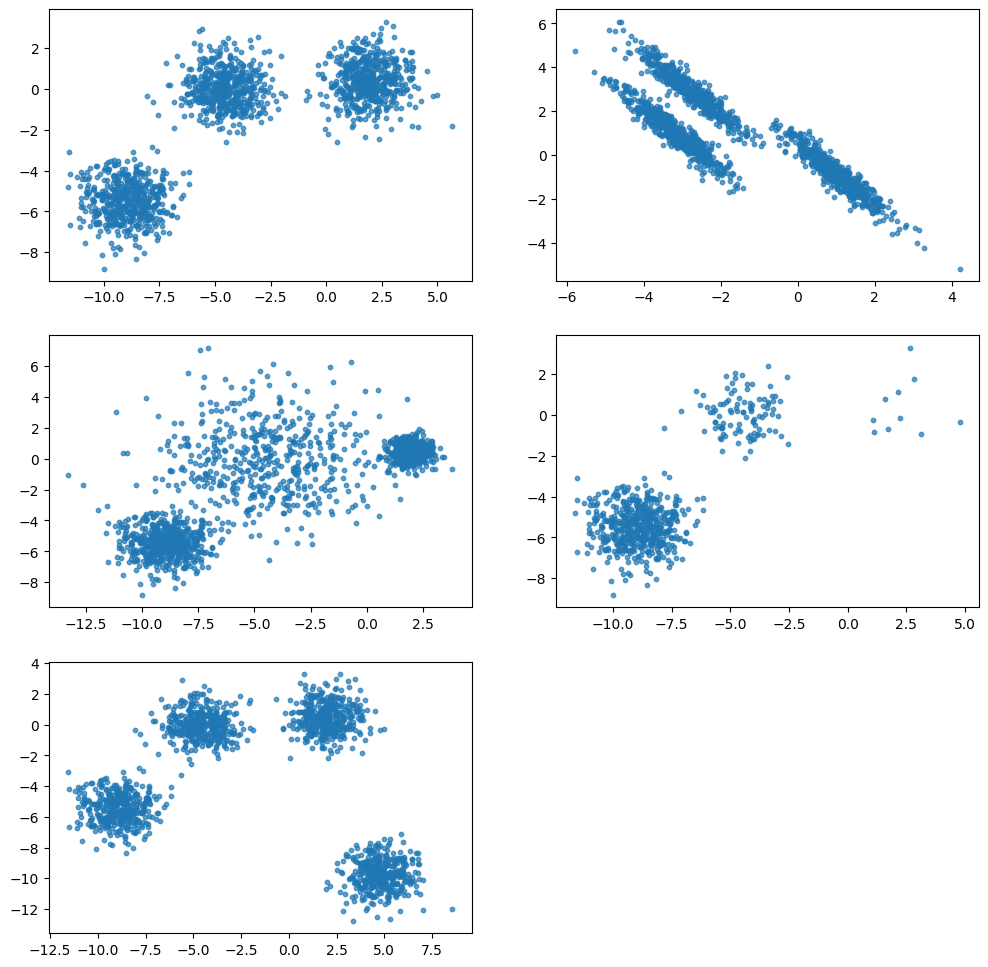

In [238]:
fig = plt.figure(figsize=(12, 12))
for i, x in enumerate(Xs):
    plt.subplot(3,2, i + 1)
    plt.scatter(x[:, 0], x[:, 1], s=10, alpha=0.7)

In [276]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

kmeans_labels = []
gmm_labels = []

for x in Xs:
    clusters = KMeans(n_clusters=3, random_state=42, n_init=3).fit_predict(x)
    kmeans_labels.append(clusters)
    
    clusters = GaussianMixture(n_components=3, random_state=42, n_init=3).fit_predict(x)
    gmm_labels.append(clusters)

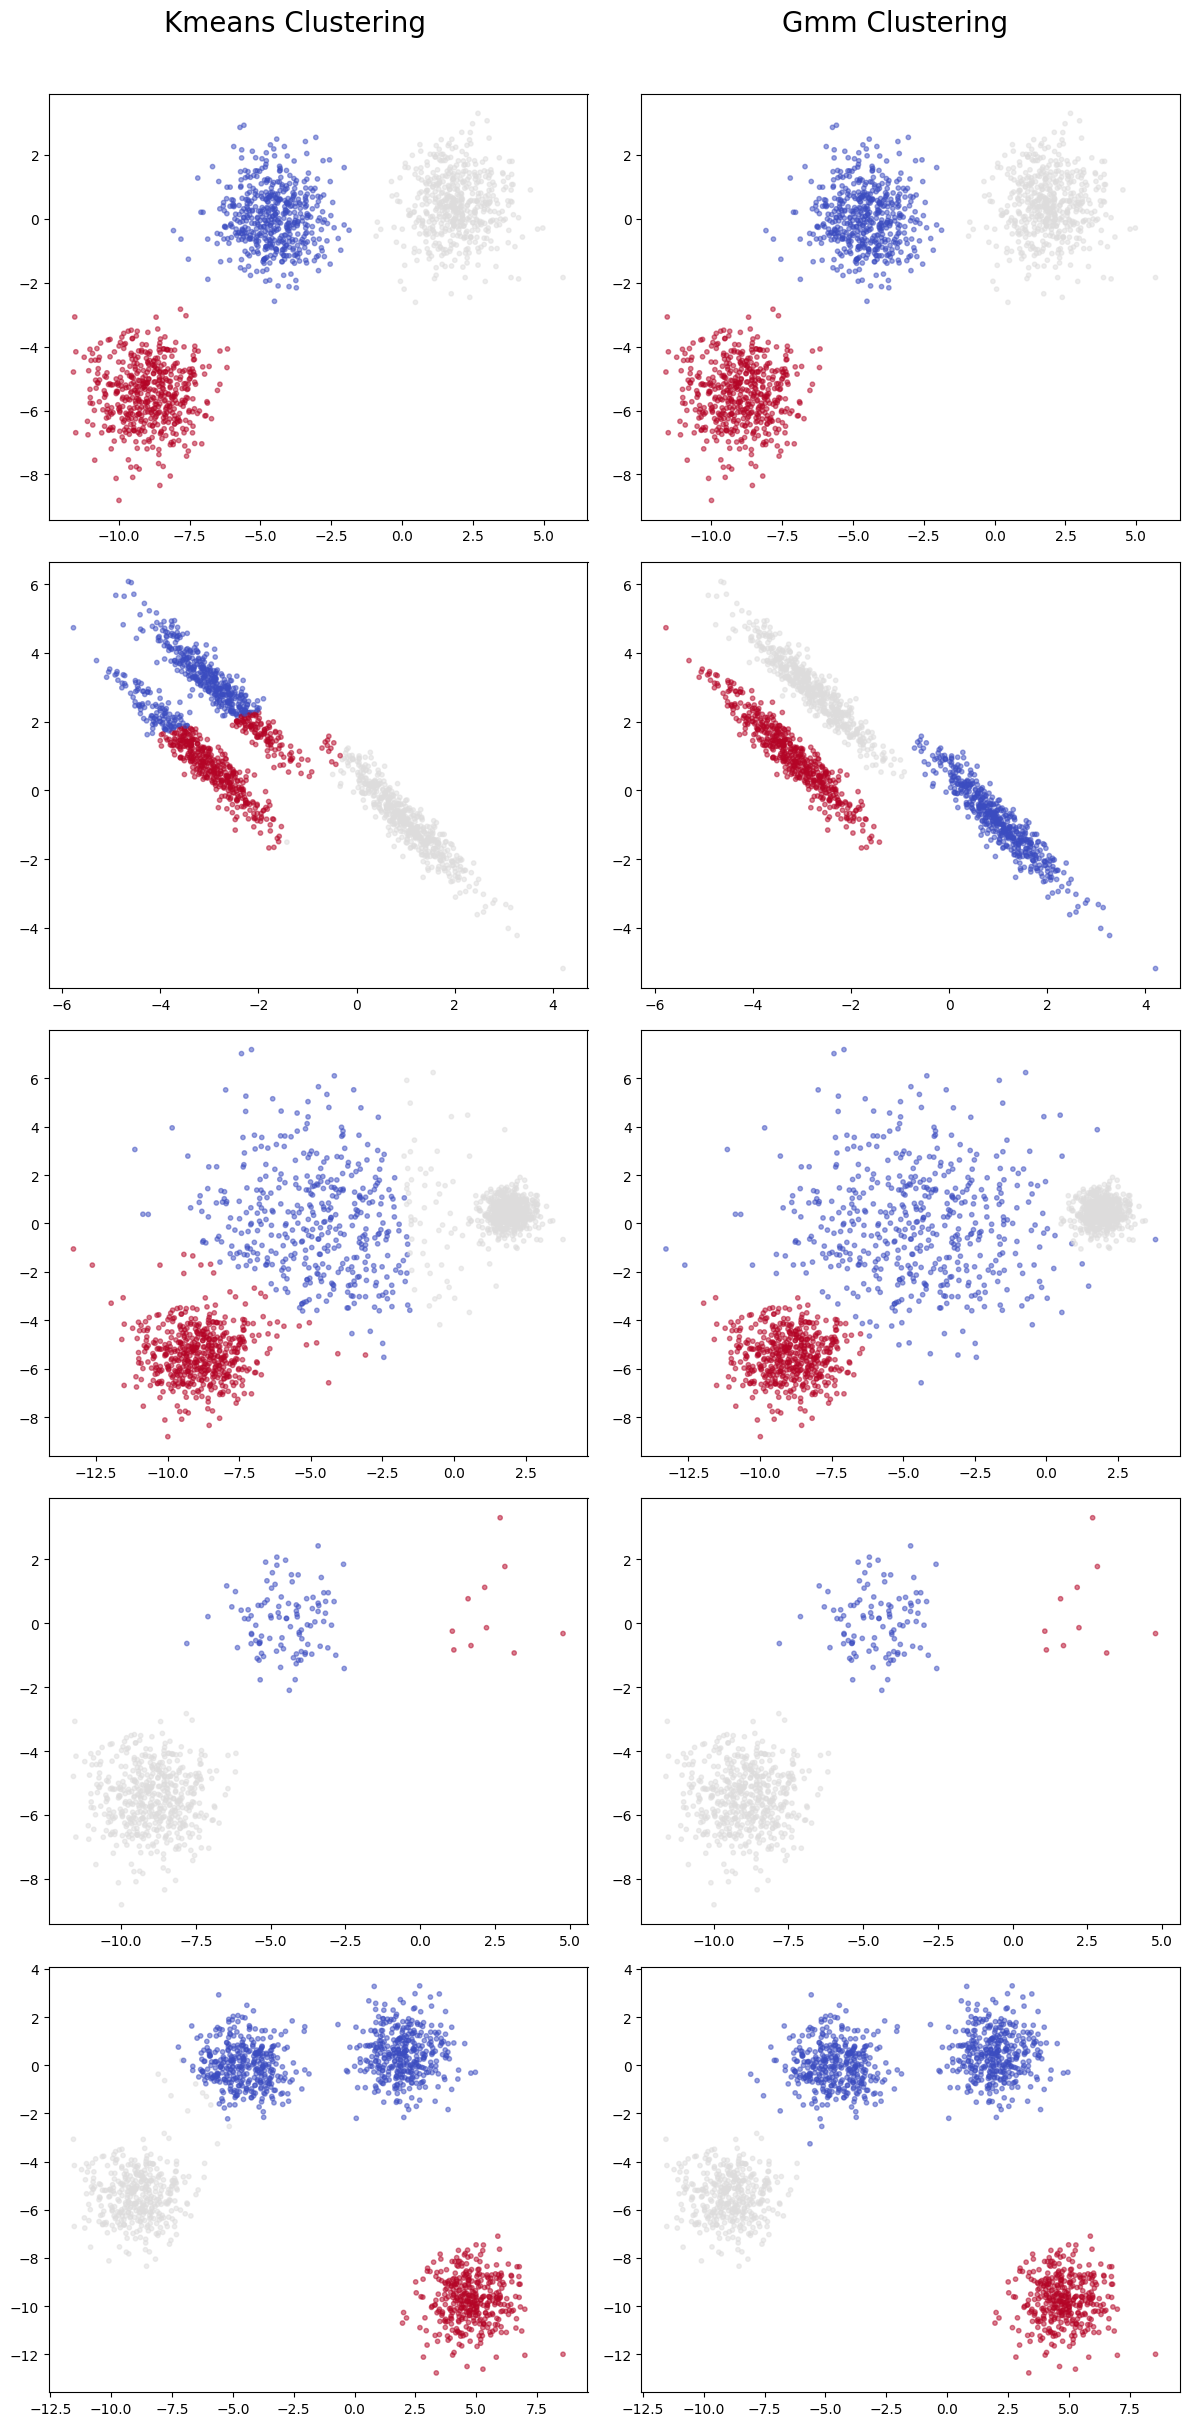

In [295]:
# i0 1 2 i1 3 4 i2 5 6
rows, cols = 5, 2
fig, axis = plt.subplots(rows, cols, figsize=(12, 24))

for i, x in enumerate(Xs):
    axis[i, 0].scatter(x[:, 0], x[:, 1], s=10, alpha=0.5, c=kmeans_labels[i], cmap='coolwarm')
    axis[i, 1].scatter(x[:, 0], x[:, 1], s=10, alpha=0.5, c=gmm_labels[i], cmap='coolwarm')

fig.text(0.25,1, "Kmeans Clustering", ha='center', fontsize=20)
fig.text(1-0.25,1, "Gmm Clustering", ha='center', fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.98])

# Ex3

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
from pathlib import Path

directory = Path('ex3_image')
def get_file(file_name : str):
    return str(directory / file_name)

img_embeddings = np.load(get_file('image_emb.npy'))
img_labels = np.load(get_file('image_labels.npy'), allow_pickle=True)

img_embeddings_test = np.load(get_file('image_emb_test.npy'))
img_labels_test = np.load(get_file('image_labels_test.npy'))

print(img_embeddings.shape, img_labels.shape)
print(img_embeddings_test.shape, img_labels_test.shape)

df = pd.DataFrame(img_labels)
uq_elems = df[0].unique()[1:]
print(uq_elems)

(42500, 512) (42500,)
(7500, 512) (7500,)
['truck' 'automobile' 'dog' 'deer' 'airplane' 'ship' 'horse' 'frog' 'cat'
 'bird']


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=len(uq_elems), random_state=42, n_init='auto')
kmeans.fit(img_embeddings)
y_pred = kmeans.predict(img_embeddings_test)

score = silhouette_score(img_embeddings_test, y_pred)
print("Silhouette Score:", score)

Silhouette Score: 0.13405385613441467


# Ex4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import Pipeline

newsgroups_train = fetch_20newsgroups()
# Create a pipeline with TfidfVectorizer and PCA
pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),
        ("pca", KernelPCA(n_components=100, random_state=42)),
    ]
)
# Fit and transform the data using the pipeline
pca_matrix = pipeline.fit_transform(newsgroups_train.data)

# Display the shape of the resulting matrix
print("Shape of PCA matrix:", pca_matrix.shape)

Shape of PCA matrix: (11314, 100)


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(pca_matrix)
print("silhouette_score:", silhouette_score(pca_matrix, labels))
print("Inertia", kmeans.inertia_)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
matrix_2d = tsne.fit_transform(pca_matrix)

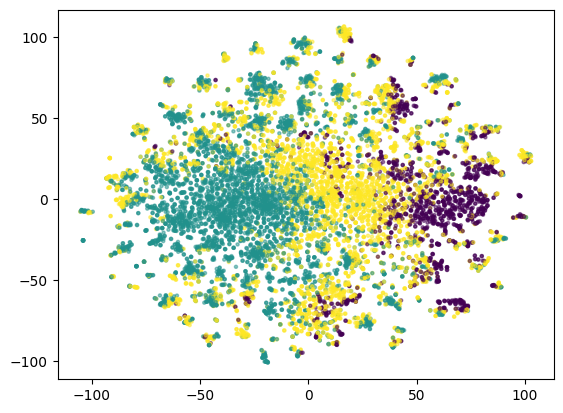

In [35]:
plt.scatter(matrix_2d[:, 0], matrix_2d[:, 1], c=cluster_labels, s=5, alpha=0.5)

In [116]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def evaluate_kmeans_on_matrix(pca_matrix, k_clusters):
    wcss_lst = []
    silh_score_lst = []
    labels_lst = []

    for k in k_clusters:
        print(f"Evaluating k={k}")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(pca_matrix)
        
        silh_score_lst.append(silhouette_score(pca_matrix, labels))
        wcss_lst.append(kmeans.inertia_)
        labels_lst.append(labels)
    return wcss_lst, silh_score_lst, labels_lst

In [117]:
k_clusters = 2 ** np.arange(1, 10, 1)
wcss_lst, silh_score_lst, labels_lst = evaluate_kmeans_on_matrix(pca_matrix, k_clusters)

Evaluating k=2
Evaluating k=4
Evaluating k=8
Evaluating k=16
Evaluating k=32
Evaluating k=64
Evaluating k=128
Evaluating k=256
Evaluating k=512


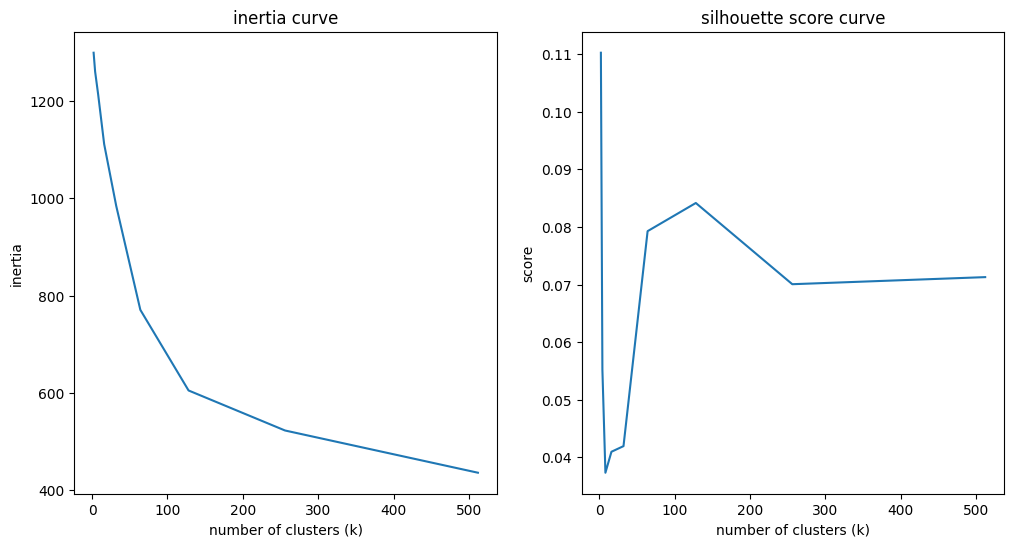

In [118]:
def plot_interia_and_silhouette(k_clusters, wcss_lst, silh_score_lst):
    plt.figure(figsize=(12, 6))
    plt.subplot(121)
    plt.plot(k_clusters, wcss_lst)
    plt.title("inertia curve")
    plt.xlabel("number of clusters (k)")
    plt.ylabel("inertia")

    plt.subplot(122)
    plt.plot(k_clusters, silh_score_lst)
    plt.title("silhouette score curve")
    plt.xlabel("number of clusters (k)")
    plt.ylabel("score")
    plt.show()
    
plot_interia_and_silhouette(k_clusters, wcss_lst, silh_score_lst)

Evaluating k=128
Evaluating k=136
Evaluating k=144
Evaluating k=152
Evaluating k=160
Evaluating k=168
Evaluating k=176
Evaluating k=184
Evaluating k=192


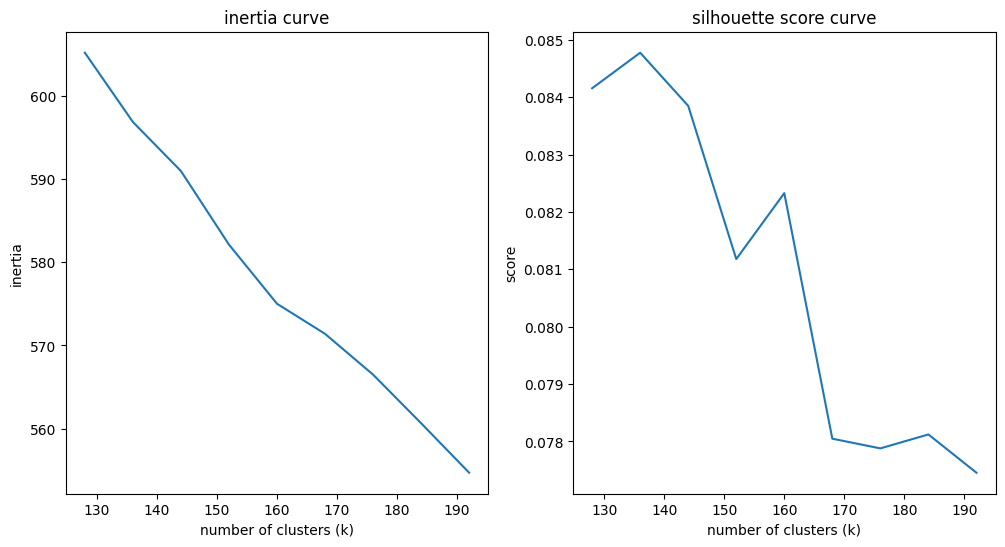

In [119]:
k_clusters = np.arange(128, 200, 8)
wcss_lst, silh_score_lst, _ = evaluate_kmeans_on_matrix(pca_matrix, k_clusters)
plot_interia_and_silhouette(k_clusters, wcss_lst, silh_score_lst)

Evaluating k=136
Evaluating k=137
Evaluating k=138
Evaluating k=139


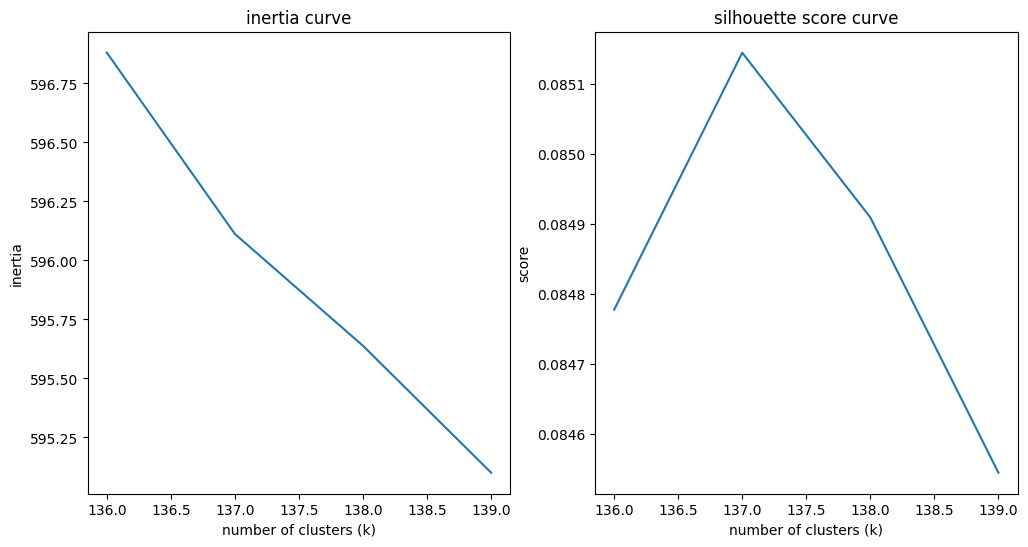

In [120]:
k_clusters = np.arange(136, 140, 1)
wcss_lst, silh_score_lst, labels_lst = evaluate_kmeans_on_matrix(pca_matrix, k_clusters)
plot_interia_and_silhouette(k_clusters, wcss_lst, silh_score_lst)

137 0.08514478273997068


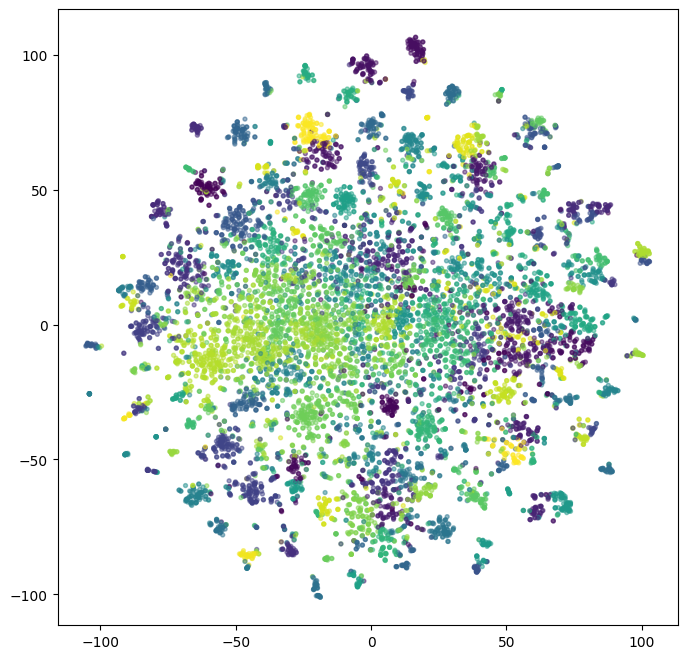

In [121]:
max_silh_index = np.argmax(silh_score_lst)
cluster_labels = labels_lst[max_silh_index]

print(k_clusters[max_silh_index], silh_score_lst[max_silh_index])

plt.figure(figsize=(8, 8))
plt.scatter(matrix_2d[:, 0], matrix_2d[:, 1], c=cluster_labels, s=8, alpha=0.5)
plt.show()

# Ex5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

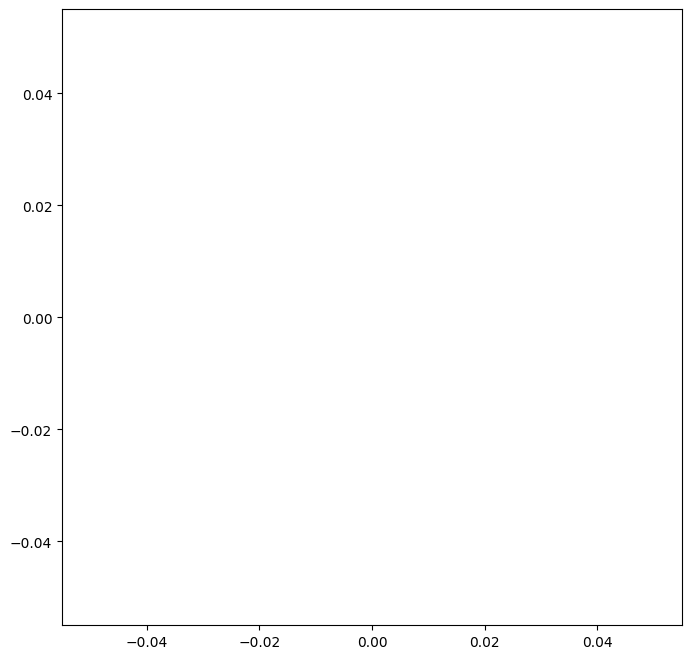

In [ ]:
from matplotlib.animation import FuncAnimation

plt.figure(figsize=(8,8))
sc = plt.scatter([], [])
cent = plt.scatter([], [], marker='x', c='red', s=50)

def get_data_from_frame(frame):
    pass

def init():
    sc.set_offsets([])
    sc.set_array([])
    cent.set_offsets([])
    return sc, cent

def update(frame):
    pts, labels, cents = get_data_from_frame(frame)
    
    sc.set_offsets(pts)
    sc.set_array(labels)
    cent.set_offsets(cents)


In [13]:
pca_matrix = np.load('ex4_files/pca_matrix.npy')
pca_matrix.shape

(11314, 100)

In [ ]:
class GigaChadKMeans:
    def __init__(self, X, n_clusters=2, random_state=0, n_init=1):
        self.X = X
        self.step = int(X.shape[0] / 10)
        self.idx = 0
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init
        
    def online_fit(self, X : np.ndarray):
        def calculate_dista
        
    def pretrain(self):
        self.idx = 3 * self.step
        chunk = self.X[:self.idx]
        self.kmeans.fit(chunk)
        
        labels = self.kmeans.predict(self.X)
        return chunk, labels, self.kmeans.cluster_centers_
        
    def do_step(self):
        if self.idx >= self.X.shape[0]:
            return None, None, None
        
        next_idx = min(self.idx + self.step, self.X.shape[0])
        chunk = self.X[:next_idx]
        self.kmeans.fit(chunk)
        
        labels = self.kmeans.predict(self.X)
        self.idx = next_idx
        return chunk, labels, self.kmeans.cluster_centers_
    
giga_kmeans = GigaChadKMeans(pca_matrix, n_clusters=10, random_state=42, n_init='auto')

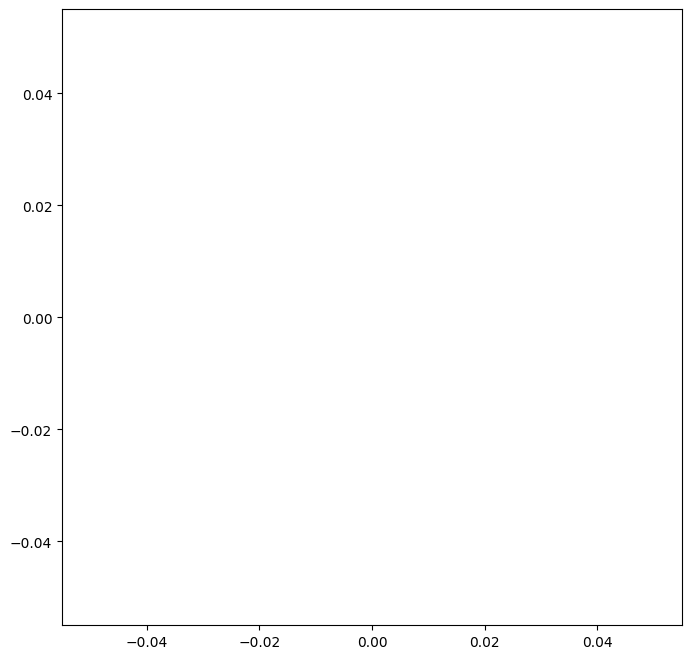

In [17]:
from matplotlib.animation import FuncAnimation

plt.figure(figsize=(8,8))
sc = plt.scatter([], [])
cent = plt.scatter([], [], marker='x', c='red', s=50)

def get_data_from_frame(frame):
    if frame == 0:
        return giga_kmeans.pretrain()
    else:
        return giga_kmeans.do_step()

def init():
    sc.set_offsets(np.empty((0, 2)))
    sc.set_array(np.array([]))
    cent.set_offsets(np.empty((0, 2)))
    return sc, cent

def update(frame):
    pts, labels, cents = get_data_from_frame(frame)
    
    sc.set_offsets(pts)
    sc.set_array(labels)
    cent.set_offsets(cents)
    return sc, cent

anim = FuncAnimation(plt.gcf(), update, frames=15, init_func=init, interval=1000, repeat=False)
